In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
RAW_DIR = Path("../data/raw")

files = list(RAW_DIR.iterdir())

for file in files:
    print(file.name)

online_retail_II.xlsx


In [3]:
file_path = Path("../data/raw/online_retail_II.xlsx")

xls = pd.ExcelFile(file_path)

print("Number of sheets:", len(xls.sheet_names))
print("Sheet names:", xls.sheet_names)

Number of sheets: 2
Sheet names: ['Year 2009-2010', 'Year 2010-2011']


In [4]:
sheets = pd.read_excel(
    file_path,
    sheet_name=None
)

print("Sheets loaded:")
for name, data in sheets.items():
    print(f"{name}: {data.shape}")

df = pd.concat(sheets.values(), ignore_index=True)

print("\nCombined shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Sheets loaded:
Year 2009-2010: (525461, 8)
Year 2010-2011: (541910, 8)

Combined shape: (1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
print("===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isna().sum())

print("\n===== DUPLICATE ROWS =====")
print("Duplicate rows:", df.duplicated().sum())

print("\n===== MEMORY USAGE =====")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

===== FIRST 5 ROWS =====


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom



===== DATA TYPES =====
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

===== MISSING VALUES =====
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

===== DUPLICATE ROWS =====
Duplicate rows: 34335

===== MEMORY USAGE =====
249.05 MB


In [6]:
print("===== UNIQUE VALUES =====")

for col in df.columns:
    print(f"{col}: {df[col].nunique(dropna=False):,}")

print("\n===== INVOICE SAMPLE =====")
print(df["Invoice"].value_counts().head(10))

print("\n===== STOCKCODE SAMPLE =====")
print(df["StockCode"].value_counts().head(10))

print("\n===== QUANTITY SUMMARY =====")
print(df["Quantity"].describe())

print("\n===== PRICE SUMMARY =====")
print(df["Price"].describe())

print("\n===== CUSTOMER ID SAMPLE =====")
print(df["Customer ID"].dropna().head(10).tolist())

print("\n===== COUNTRY COUNTS =====")
print(df["Country"].value_counts().head(20))

===== UNIQUE VALUES =====
Invoice: 53,628
StockCode: 5,305
Description: 5,699
Quantity: 1,057
InvoiceDate: 47,635
Price: 2,807
Customer ID: 5,943
Country: 43

===== INVOICE SAMPLE =====
Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
536592    1184
537823    1182
537240    1136
573585    1114
537666    1072
Name: count, dtype: int64

===== STOCKCODE SAMPLE =====
StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
Name: count, dtype: int64

===== QUANTITY SUMMARY =====
count   1067371.00
mean          9.94
std         172.71
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64

===== PRICE SUMMARY =====
count   1067371.00
mean          4.65
std         123.55
min      -53594.36
25%           1.25
50%           2.10
75%           4.15
max       38970.00
Name: Price, dtype: fl

In [7]:
print("===== INVOICE PREFIXES =====")

invoice_str = df["Invoice"].astype(str)

print(
    invoice_str.str[0]
    .value_counts(dropna=False)
)

print("\n===== INVOICES STARTING WITH C =====")

cancelled = invoice_str.str.upper().str.startswith("C")

print("Cancelled-looking rows:", cancelled.sum())
print("Percentage:", f"{cancelled.mean() * 100:.2f}%")

print("\nSample:")
display(df.loc[cancelled].head(10))

print("\n===== NEGATIVE QUANTITY =====")

negative_qty = df["Quantity"] < 0

print("Rows:", negative_qty.sum())
print("Percentage:", f"{negative_qty.mean() * 100:.2f}%")

print("\nSample:")
display(df.loc[negative_qty].head(10))

print("\n===== ZERO/NEGATIVE PRICE =====")

invalid_price = df["Price"] <= 0

print("Rows:", invalid_price.sum())
print("Percentage:", f"{invalid_price.mean() * 100:.2f}%")

print("\nSample:")
display(df.loc[invalid_price].head(10))

===== INVOICE PREFIXES =====
Invoice
5    939382
4    108489
C     19494
A         6
Name: count, dtype: int64

===== INVOICES STARTING WITH C =====
Cancelled-looking rows: 19494
Percentage: 1.83%

Sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom



===== NEGATIVE QUANTITY =====
Rows: 22950
Percentage: 2.15%

Sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom



===== ZERO/NEGATIVE PRICE =====
Rows: 6207
Percentage: 0.58%

Sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom


In [8]:
print("===== CANCELLATION vs NEGATIVE QUANTITY =====")

print("C invoices + negative quantity:")
print((cancelled & negative_qty).sum())

print("\nC invoices + non-negative quantity:")
print((cancelled & ~negative_qty).sum())

print("\nNegative quantity + non-C invoice:")
print((negative_qty & ~cancelled).sum())

print("\n===== PRICE BY TRANSACTION TYPE =====")

print(
    df.groupby(
        pd.Series(
            np.select(
                [
                    cancelled,
                    negative_qty,
                    invalid_price
                ],
                [
                    "Cancellation",
                    "Negative Quantity",
                    "Non-positive Price"
                ],
                default="Normal"
            ),
            index=df.index
        )
    )["Price"].agg(["count", "min", "max", "mean"])
)

===== CANCELLATION vs NEGATIVE QUANTITY =====
C invoices + negative quantity:
19493

C invoices + non-negative quantity:
1

Negative quantity + non-C invoice:
3457

===== PRICE BY TRANSACTION TYPE =====
                      count       min      max   mean
Cancellation          19494      0.01 38970.00  44.87
Negative Quantity      3457      0.00     0.00   0.00
Non-positive Price     2750 -53594.36     0.00 -57.70
Normal              1041670      0.00 25111.09   4.08


In [9]:
print("===== NON-C NEGATIVE QUANTITY =====")

non_c_negative = (~cancelled) & (df["Quantity"] < 0)

display(
    df.loc[
        non_c_negative,
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price",
         "Customer ID", "Country"]
    ].head(5)
)

print("\n===== ZERO PRICE =====")

zero_price = df["Price"] == 0

print("Rows:", zero_price.sum())

display(
    df.loc[
        zero_price,
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price",
         "Customer ID", "Country"]
    ].head(5)
)

print("\n===== NEGATIVE PRICE =====")

negative_price = df["Price"] < 0

print("Rows:", negative_price.sum())

display(
    df.loc[
        negative_price,
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price",
         "Customer ID", "Country"]
    ].head(5)
)

print("\n===== A-PREFIX INVOICES =====")

a_invoice = invoice_str.str.upper().str.startswith("A")

print("Rows:", a_invoice.sum())

display(df.loc[a_invoice])

===== NON-C NEGATIVE QUANTITY =====


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom



===== ZERO PRICE =====
Rows: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom



===== NEGATIVE PRICE =====
Rows: 5


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom



===== A-PREFIX INVOICES =====
Rows: 6


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [10]:
zero_price = df["Price"] == 0

print("===== ZERO-PRICE TRANSACTIONS =====")
print("Total:", zero_price.sum())

print("\nWith Customer ID:")
print(df.loc[zero_price, "Customer ID"].notna().sum())

print("\nWithout Customer ID:")
print(df.loc[zero_price, "Customer ID"].isna().sum())

print("\nTop StockCodes:")
display(
    df.loc[zero_price, "StockCode"]
      .value_counts()
      .head(5)
)

print("\nTop Descriptions:")
display(
    df.loc[zero_price, "Description"]
      .value_counts(dropna=False)
      .head(5)
)

print("\nSample zero-price rows with Customer ID:")
display(
    df.loc[
        zero_price & df["Customer ID"].notna(),
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price",
         "Customer ID", "Country"]
    ].head(5)
)

===== ZERO-PRICE TRANSACTIONS =====
Total: 6202

With Customer ID:
71

Without Customer ID:
6131

Top StockCodes:


StockCode
22501     18
46000M    18
79321     17
22423     16
21116     16
Name: count, dtype: int64


Top Descriptions:


Description
NaN        4382
check       162
?            92
damages      84
damaged      81
Name: count, dtype: int64


Sample zero-price rows with Customer ID:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.00,16126.00,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.00,15658.00,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.00,17231.00,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.00,14108.00,United Kingdom


In [11]:
duplicates = df[df.duplicated(keep=False)].copy()

print("Total rows involved in duplicate groups:", len(duplicates))
print("Duplicate rows reported by duplicated():", df.duplicated().sum())

print("\n===== DUPLICATE GROUPS =====")

duplicate_counts = (
    duplicates
    .groupby(list(df.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
)

display(duplicate_counts.head(5).to_frame("count"))

print("\n===== EXAMPLE DUPLICATE ROWS =====")

display(
    duplicates.sort_values(
        ["Invoice", "StockCode", "InvoiceDate"]
    ).head(5)
)

Total rows involved in duplicate groups: 67242
Duplicate rows reported by duplicated(): 34335

===== DUPLICATE GROUPS =====


count
Invoice StockCode Description                         Quantity InvoiceDate         Price Customer ID Country              
555524  22698     PINK REGENCY TEACUP AND SAUCER      1        2011-06-05 11:37:00 2.95  16923.00    United Kingdom     20
        22697     GREEN REGENCY TEACUP AND SAUCER     1        2011-06-05 11:37:00 2.95  16923.00    United Kingdom     12
537224  70007     HI TEC ALPINE HAND WARMER           1        2010-12-05 16:24:00 1.65  13174.00    United Kingdom     10
572861  22775     PURPLE DRAWERKNOB ACRYLIC EDWARDIAN 12       2011-10-26 12:46:00 1.25  14102.00    United Kingdom      8
537422  22585     PACK OF 6 BIRDY GIFT TAGS           2        2010-12-06 15:27:00 1.25  17812.00    United Kingdom      6


===== EXAMPLE DUPLICATE ROWS =====


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom


In [12]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("After removing exact duplicates:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

Original shape: (1067371, 8)
After removing exact duplicates: (1033036, 8)
Duplicates remaining: 0


In [13]:
# Transaction quality flags
is_cancelled = df_clean["Invoice"].astype(str).str.upper().str.startswith("C")
is_negative_qty = df_clean["Quantity"] < 0
is_zero_price = df_clean["Price"] == 0
is_negative_price = df_clean["Price"] < 0
is_missing_customer = df_clean["Customer ID"].isna()
is_not_uk = df_clean["Country"].ne("United Kingdom")

In [14]:
print("===== FILTERING IMPACT =====")

print(f"Cancellation invoices : {is_cancelled.sum():,}")
print(f"Negative quantity     : {is_negative_qty.sum():,}")
print(f"Zero price            : {is_zero_price.sum():,}")
print(f"Negative price        : {is_negative_price.sum():,}")
print(f"Missing Customer ID   : {is_missing_customer.sum():,}")
print(f"Non-UK transactions   : {is_not_uk.sum():,}")


===== FILTERING IMPACT =====
Cancellation invoices : 19,104
Negative quantity     : 22,496
Zero price            : 6,014
Negative price        : 5
Missing Customer ID   : 235,151
Non-UK transactions   : 84,715


In [15]:
print("\n===== OVERALL =====")

valid_mask = (
    ~is_cancelled
    & (df_clean["Quantity"] > 0)
    & (df_clean["Price"] > 0)
    & df_clean["Customer ID"].notna()
    & df_clean["Country"].eq("United Kingdom")
)

print(f"Valid UK transactions: {valid_mask.sum():,}")
print(f"Removed transactions : {(~valid_mask).sum():,}")
print(f"Remaining percentage : {valid_mask.mean() * 100:.2f}%")


===== OVERALL =====
Valid UK transactions: 700,388
Removed transactions : 332,648
Remaining percentage : 67.80%


In [16]:
df_uk = df_clean.loc[valid_mask].copy()

print("Clean UK transaction dataset")
print("=" * 40)

print("Shape:", df_uk.shape)
print("Rows:", f"{len(df_uk):,}")
print("Columns:", df_uk.shape[1])

print("\nMissing values:")
print(df_uk.isna().sum())

print("\nValidation checks:")
print("Negative quantity:", (df_uk["Quantity"] < 0).sum())
print("Non-positive price:", (df_uk["Price"] <= 0).sum())
print("Missing Customer ID:", df_uk["Customer ID"].isna().sum())
print("Non-UK:", (df_uk["Country"] != "United Kingdom").sum())
print("Cancellation invoices:",
      df_uk["Invoice"].astype(str).str.startswith("C").sum())

Clean UK transaction dataset
Shape: (700388, 8)
Rows: 700,388
Columns: 8

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Validation checks:
Negative quantity: 0
Non-positive price: 0
Missing Customer ID: 0
Non-UK: 0
Cancellation invoices: 0


In [17]:
print("===== DATE RANGE =====")
print("First transaction:", df_uk["InvoiceDate"].min())
print("Last transaction :", df_uk["InvoiceDate"].max())

print("\n===== CUSTOMER COUNT =====")
print("Unique customers:", df_uk["Customer ID"].nunique())

print("\n===== TRANSACTIONS PER CUSTOMER =====")

transactions_per_customer = df_uk.groupby("Customer ID").size()

print(transactions_per_customer.describe())

===== DATE RANGE =====
First transaction: 2009-12-01 07:45:00
Last transaction : 2011-12-09 12:49:00

===== CUSTOMER COUNT =====
Unique customers: 5350

===== TRANSACTIONS PER CUSTOMER =====
count    5350.00
mean      130.91
std       313.46
min         1.00
25%        20.00
50%        52.00
75%       137.00
max     12435.00
dtype: float64


In [18]:
df_uk["Revenue"] = df_uk["Quantity"] * df_uk["Price"]

print(df_uk[["Quantity", "Price", "Revenue"]].head())
print("\nRevenue summary:")
print(df_uk["Revenue"].describe())

   Quantity  Price  Revenue
0        12   6.95    83.40
1        12   6.75    81.00
2        12   6.75    81.00
3        48   2.10   100.80
4        24   1.25    30.00

Revenue summary:
count   700388.00
mean        20.54
std        237.75
min          0.00
25%          4.25
50%         10.50
75%         17.85
max     168469.60
Name: Revenue, dtype: float64


In [19]:
reference_date = df_uk["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_df = (
    df_uk.groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
    )
    .reset_index()
)

# Average Order Value
customer_df["Average_Order_Value"] = (
    customer_df["Monetary"] / customer_df["Frequency"]
)

print("Customer-level shape:", customer_df.shape)
display(customer_df.head())

/tmp/ipykernel_14481/2010800205.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  reference_date = df_uk["InvoiceDate"].max() + pd.Timedelta(days=1)


Customer-level shape: (5350, 7)


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Average_Order_Value
0,12346.00,326,12,77556.46,74285,27,6463.04
1,12608.00,405,1,415.79,323,16,415.79
2,12745.00,487,2,723.85,467,20,361.93
3,12746.00,541,1,254.55,97,17,254.55
4,12747.00,2,26,8898.48,2640,85,342.25


In [20]:
print("===== CUSTOMER DATA TYPES =====")
print(customer_df.dtypes)

print("\n===== MISSING VALUES =====")
print(customer_df.isna().sum())

print("\n===== DUPLICATE CUSTOMERS =====")
print(customer_df["Customer ID"].duplicated().sum())

print("\n===== FEATURE SUMMARY =====")
display(customer_df.describe().T)

print("\n===== NON-POSITIVE VALUES =====")

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Average_Order_Value",
    "Unique_Products",
]

for col in features:
    print(f"{col}: {(customer_df[col] <= 0).sum():,}")

===== CUSTOMER DATA TYPES =====
Customer ID            float64
Recency                  int64
Frequency                int64
Monetary               float64
Total_Quantity           int64
Unique_Products          int64
Average_Order_Value    float64
dtype: object

===== MISSING VALUES =====
Customer ID            0
Recency                0
Frequency              0
Monetary               0
Total_Quantity         0
Unique_Products        0
Average_Order_Value    0
dtype: int64

===== DUPLICATE CUSTOMERS =====
0

===== FEATURE SUMMARY =====


,count,mean,std,min,25%,50%,75%,max
Customer ID,5350.00,15557.36,1581.16,12346.00,14191.25,15565.50,16922.75,18287.00
Recency,5350.00,203.00,209.96,1.00,26.00,98.50,382.00,739.00
Frequency,5350.00,6.27,12.00,1.00,1.00,3.00,7.00,336.00
Monetary,5350.00,2689.58,11706.53,2.95,330.20,829.44,2156.25,580987.04
Total_Quantity,5350.00,1594.84,6287.19,1.00,180.25,464.50,1295.00,188201.00
Unique_Products,5350.00,81.55,112.23,1.00,18.00,44.00,102.75,2286.00
Average_Order_Value,5350.00,358.98,1244.91,2.95,172.25,269.73,393.12,84236.25



===== NON-POSITIVE VALUES =====
Recency: 0
Frequency: 0
Monetary: 0
Total_Quantity: 0
Average_Order_Value: 0
Unique_Products: 0


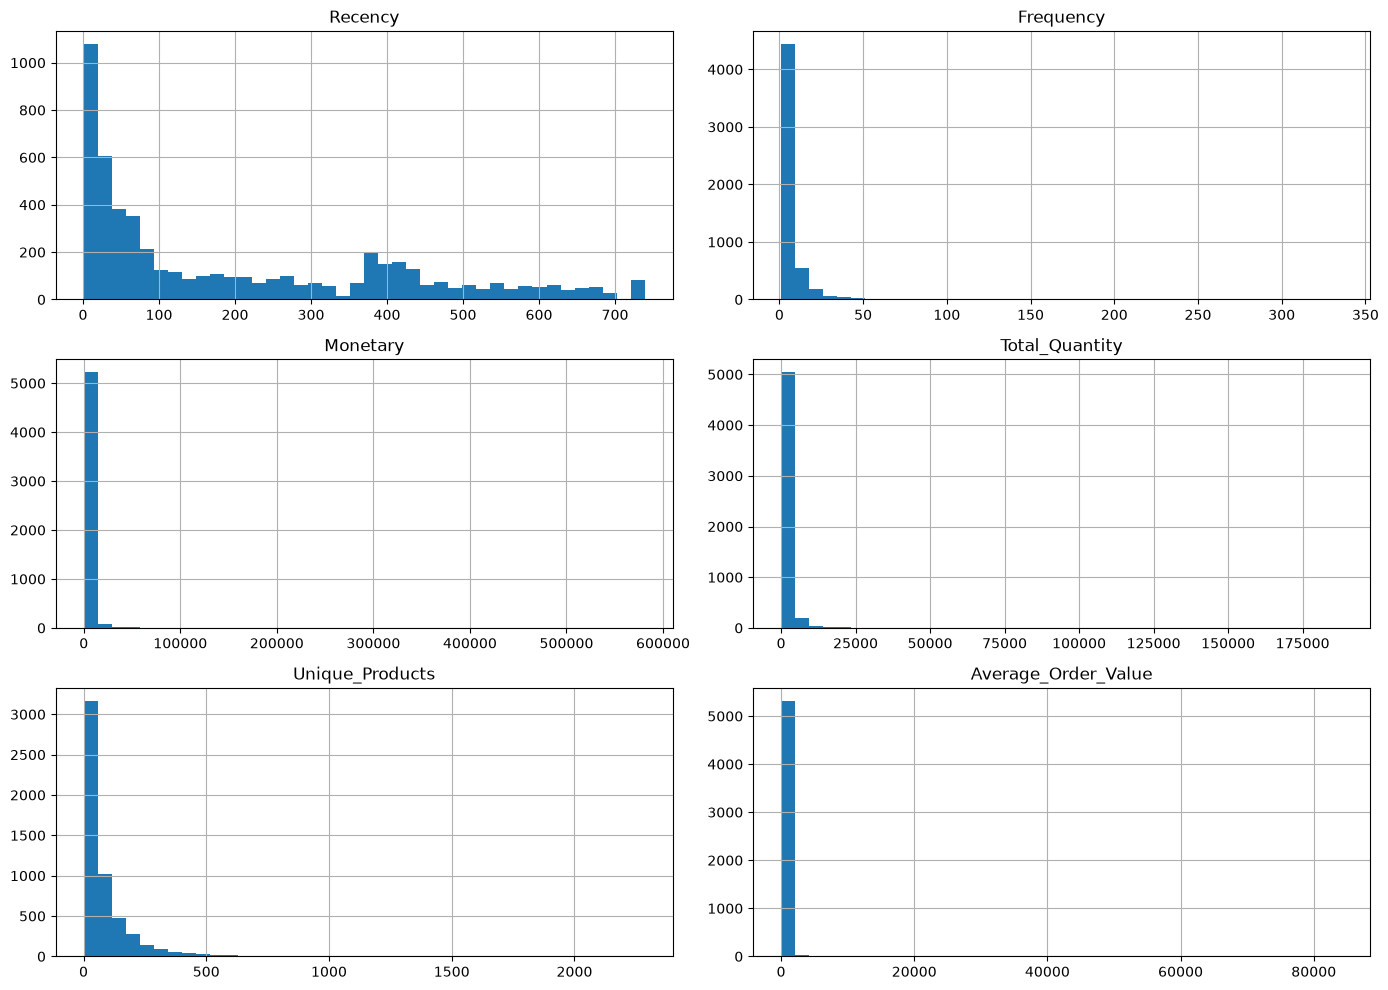

In [21]:
import matplotlib.pyplot as plt

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Average_Order_Value",
]

customer_df[features].hist(
    figsize=(14, 10),
    bins=40
)

plt.tight_layout()
plt.show()

In [22]:
skewness = customer_df[features].skew().sort_values(ascending=False)

print("===== FEATURE SKEWNESS =====")
display(skewness.to_frame("Skewness"))

===== FEATURE SKEWNESS =====


,Skewness
Average_Order_Value,58.18
Monetary,28.19
Total_Quantity,16.31
Frequency,10.43
Unique_Products,5.17
Recency,0.87


In [23]:
output_path = Path("../data/processed/customer_features_raw.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

customer_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {customer_df.shape}")

Saved: ../data/processed/customer_features_raw.csv
Shape: (5350, 7)


# Notebook 1 — Data Understanding & EDA

## 1. Objective

The objective of this notebook was to understand the raw Online Retail II dataset, investigate data quality issues, clean the transaction-level data, restrict the analysis to UK customers, and create an initial customer-level dataset for the clustering project.

---

## 2. Dataset Overview

The raw dataset contains two yearly sheets:

| Sheet          |          Rows | Columns |
| -------------- | ------------: | ------: |
| Year 2009-2010 |       525,461 |       8 |
| Year 2010-2011 |       541,910 |       8 |
| **Combined**   | **1,067,371** |   **8** |

The original columns are:

* `Invoice`
* `StockCode`
* `Description`
* `Quantity`
* `InvoiceDate`
* `Price`
* `Customer ID`
* `Country`

The dataset is **transaction-level data**, meaning one row represents an item/transaction record rather than one customer.

---

## 3. Initial Data Quality Investigation

The following issues were investigated:

* Missing values
* Exact duplicate rows
* Negative quantities
* Zero and negative prices
* Cancellation invoices
* Accounting adjustment records
* Missing customer identifiers
* Country distribution
* Transaction dates
* Quantity and price distributions

### Missing Values

The main missing-value problem was `Customer ID`.

| Column      | Missing Values |
| ----------- | -------------: |
| Description |          4,382 |
| Customer ID |        243,007 |

Missing `Customer ID` records cannot reliably be assigned to a customer, so they cannot be used for customer-level segmentation.

---

## 4. Duplicate Analysis

The raw dataset contained:

**34,335 exact duplicate rows.**

These duplicates were removed because retaining them could artificially inflate customer-level metrics such as:

* Frequency
* Quantity
* Revenue
* Product diversity

After removing exact duplicates:

```text
Original transactions:       1,067,371
After deduplication:         1,033,036
```

No exact duplicates remained.

---

## 5. Transaction Validity Investigation

Several types of abnormal transactions were investigated.

### Cancellation Invoices

Invoices beginning with `C` were identified as cancellation transactions.

These were excluded because they represent cancelled purchases rather than completed purchases.

### Negative Quantities

Negative quantities were investigated and found to primarily represent returns/cancellations or operational records.

These were excluded from purchase-behavior modeling.

### Zero/Negative Prices

Transactions with `Price <= 0` were investigated.

Many were operational records, damaged/check/manual records, or accounting-related entries rather than normal customer purchases.

These were excluded because they do not represent valid positive-value purchases.

### Accounting Adjustments

`A`-prefix invoices were investigated separately.

Several records represented accounting adjustments such as bad-debt adjustments rather than customer purchases. These were therefore not treated as normal purchasing behavior.

---

## 6. Customer Segmentation Scope

The project focuses specifically on **United Kingdom customers**.

Therefore, the final transaction dataset was restricted to:

```text
Country = United Kingdom
Customer ID is available
Quantity > 0
Price > 0
Invoice is not a cancellation
```

After applying these conditions:

```text
Cleaned transaction rows:       1,033,036
Valid UK purchase transactions:   700,388
```

The resulting dataset contains only transactions suitable for customer purchase-behavior analysis.

---

## 7. Why Transactions Were Aggregated to Customers

The raw dataset contains more than one million transaction rows, but clustering individual transactions would not answer our business question.

The objective is **customer segmentation**, so the unit of analysis should be the customer.

Therefore:

```text
Transaction-level data
        ↓
Group by Customer ID
        ↓
Customer-level profiles
```

The 700,388 valid UK transactions correspond to:

**5,350 unique customers.**

Thus, the final modeling population contains **5,350 customer profiles**, not 5,350 transaction records.

---

## 8. Initial Customer-Level Features

Customer behavior was aggregated into the following features:

| Feature               | Meaning                                         |
| --------------------- | ----------------------------------------------- |
| `Recency`             | Days since the customer's most recent purchase  |
| `Frequency`           | Number of unique invoices/orders                |
| `Monetary`            | Total customer revenue                          |
| `Total_Quantity`      | Total quantity purchased                        |
| `Unique_Products`     | Number of unique products purchased             |
| `Average_Order_Value` | Total monetary value divided by order frequency |

`Customer ID` was retained for identification and traceability but will **not** be used as a clustering feature.

---

## 9. Customer Feature Distribution

The customer-level features were examined for skewness.

| Feature               | Skewness |
| --------------------- | -------: |
| `Average_Order_Value` |    58.18 |
| `Monetary`            |    28.19 |
| `Total_Quantity`      |    16.31 |
| `Frequency`           |    10.43 |
| `Unique_Products`     |     5.17 |
| `Recency`             |     0.87 |

Most behavioral features are **strongly right-skewed**.

In particular, `Average_Order_Value`, `Monetary`, `Total_Quantity`, and `Frequency` contain extreme high-value customers.

This is important for clustering because distance-based algorithms such as K-Means can be disproportionately influenced by large feature values.

The feature-engineering notebook will therefore investigate appropriate transformations and scaling techniques before model training.

---

## 10. Final Notebook 1 Result

The main transformation achieved in this notebook was:

```text
1,067,371 raw transaction records
              ↓
Remove exact duplicates
              ↓
1,033,036 unique transaction records
              ↓
Remove invalid/non-customer/non-UK records
              ↓
700,388 valid UK purchase transactions
              ↓
Aggregate by Customer ID
              ↓
5,350 customer profiles
```

These **5,350 customer profiles** are the starting point for the next stage of the project.

---

## 11. Conclusion

Notebook 1 established a clean and well-understood foundation for customer segmentation.

The raw transaction data was investigated rather than blindly cleaned. Invalid, cancelled, duplicate, and non-customer records were excluded where they could not provide reliable customer purchasing behavior.

The resulting customer-level dataset contains **5,350 UK customers** with behavioral features suitable for further feature engineering.

The next notebook will focus on transforming these customer features into a **clustering-ready feature matrix**, including skewness treatment, outlier handling, feature scaling, and feature relationship analysis.
